# MLBB Hero Meta & Performance Analysis

### Project Objective
This notebook analyzes Mobile Legends: Bang Bang (MLBB) hero performance using **Pick Rate, Win Rate, Ban Rate, and Meta Score**.

The analysis is designed to answer practical questions such as:
- Which heroes have the highest and lowest win rates?
- Does hero popularity relate to performance?
- Which heroes can be considered hidden gems?
- Which metrics are most strongly related to win rate?
- Which heroes have the highest overall Meta Score?

The goal is to move from **data understanding → data cleaning → exploratory analysis → insights → meta analysis**.


In [64]:
# Import the libraries required for data analysis and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
# Load the MLBB hero ranking dataset into a Pandas DataFrame.
# The DataFrame will be our main object for all analysis in this notebook.
df = pd.read_csv("/content/mlbb_api_ranking.csv")

## 1. Understand the Dataset
First, inspect the dataset structure, size, columns, data types, and basic statistics.

In [66]:
# Display the first five rows to get a quick look at the dataset.
# This helps us understand what one record/row represents.
df.head()

,Rank,Hero,Pick Rate (%),Win Rate (%),Ban Rate (%),Scraped_At,META Score
0,1,Aulus,0.95,59.32,12.95,2026-09-30T20:56:58.202807,20.08
1,2,Rafaela,1.21,59.27,16.30,2026-09-30T20:56:58.202820,25.42
2,3,Masha,0.70,59.16,26.08,2026-09-30T20:56:58.202826,22.95
3,4,Marcel,0.27,58.16,32.65,2026-09-30T20:56:58.202831,19.88
4,5,Argus,0.60,55.41,1.43,2026-09-30T20:56:58.202837,6.96


In [67]:
# Check the number of rows and columns in the dataset.
# Rows = number of heroes/records, Columns = number of variables.
df.shape

(133, 7)

In [68]:
# Display all column names so we know which variables are available for analysis.
df.columns

Index(['Rank', 'Hero', 'Pick Rate (%)', 'Win Rate (%)', 'Ban Rate (%)',
       'Scraped_At', 'META Score'],
      dtype='object')

In [69]:
# Check column data types and whether every column contains non-null values.
# This helps identify potential data-quality issues before analysis.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           133 non-null    int64  
 1   Hero           133 non-null    object 
 2   Pick Rate (%)  133 non-null    float64
 3   Win Rate (%)   133 non-null    float64
 4   Ban Rate (%)   133 non-null    float64
 5   Scraped_At     133 non-null    object 
 6   META Score     133 non-null    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 7.4+ KB


In [70]:
# Generate descriptive statistics for the numerical columns.
# This shows the count, mean, standard deviation, minimum, quartiles, and maximum.
df.describe()

,Rank,Pick Rate (%),Win Rate (%),Ban Rate (%),META Score
count,133.00000,133.000000,133.000000,133.000000,133.000000
mean,67.00000,0.751805,49.921579,5.518797,6.518571
std,38.53786,0.538523,3.068982,11.582493,8.317577
min,1.00000,0.040000,41.430000,0.040000,-1.840000
25%,34.00000,0.360000,48.180000,0.270000,1.690000
50%,67.00000,0.620000,49.700000,1.180000,3.530000
75%,100.00000,0.940000,51.620000,4.390000,7.290000
max,133.00000,2.950000,59.320000,65.850000,42.010000


## 2. Data Quality Checks
Before analyzing the data, check for missing values, duplicate rows, and the number of unique values in each column.

In [71]:
# Count missing values in every column.
# A value of 0 means that column has no missing records.
df.isnull().sum()

,0
Rank,0
Hero,0
Pick Rate (%),0
Win Rate (%),0
Ban Rate (%),0
Scraped_At,0
META Score,0


In [72]:
# Count completely duplicated rows.
# Duplicate rows can lead to incorrect results, so we check them before analysis.
df.duplicated().sum()

np.int64(0)

In [73]:
# Check how many unique values are present in each column.
# This helps us understand which columns identify individual heroes
# and which columns contain repeated values.
for col in df.columns:
    print(col, df[col].nunique())

Rank 133
Hero 133
Pick Rate (%) 88
Win Rate (%) 122
Ban Rate (%) 105
Scraped_At 133
META Score 125


In [74]:
# Examine the statistical distribution of Win Rate.
# We use this later as a benchmark for identifying high- and low-performing heroes.
df["Win Rate (%)"].describe()

,Win Rate (%)
count,133.000000
mean,49.921579
std,3.068982
min,41.430000
25%,48.180000
50%,49.700000
75%,51.620000
max,59.320000


In [75]:
# Examine the statistical distribution of Pick Rate.
# Pick Rate represents how frequently a hero is selected.
df["Pick Rate (%)"].describe()

,Pick Rate (%)
count,133.000000
mean,0.751805
std,0.538523
min,0.040000
25%,0.360000
50%,0.620000
75%,0.940000
max,2.950000


In [76]:
# Examine the statistical distribution of Ban Rate.
# Ban Rate helps indicate how frequently a hero is prevented from being selected.
df["Ban Rate (%)"].describe()

,Ban Rate (%)
count,133.000000
mean,5.518797
std,11.582493
min,0.040000
25%,0.270000
50%,1.180000
75%,4.390000
max,65.850000


## 3. Standardize Column Names
The original column names contain spaces and special characters. We convert them into easier-to-use lowercase names.

In [77]:
# Standardize column names to make them easier to use in Python.
# Steps:
# 1. Convert names to lowercase.
# 2. Remove extra spaces.
# 3. Replace spaces with underscores.
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

In [78]:
# Verify the updated column names after standardization.
df.columns

Index(['rank', 'hero', 'pick_rate_(%)', 'win_rate_(%)', 'ban_rate_(%)',
       'scraped_at', 'meta_score'],
      dtype='object')

## 4. Hero Win Rate Analysis
Identify the top-performing and lowest-performing heroes based on win rate.

In [79]:
# Sort heroes by Win Rate from highest to lowest.
# Then select the top 10 heroes to identify the strongest performers in the dataset.
top_winrate = df.sort_values(
    "win_rate_(%)",
    ascending=False
).head(10)

# Display the hero name and its Win Rate.
top_winrate[["hero", "win_rate_(%)"]]

,hero,win_rate_(%)
0,Aulus,59.32
1,Rafaela,59.27
2,Masha,59.16
3,Marcel,58.16
4,Argus,55.41
5,Minotaur,55.10
6,Khufra,54.59
7,Popol and Kupa,54.32
8,Lolita,54.26
9,Gloo,54.10


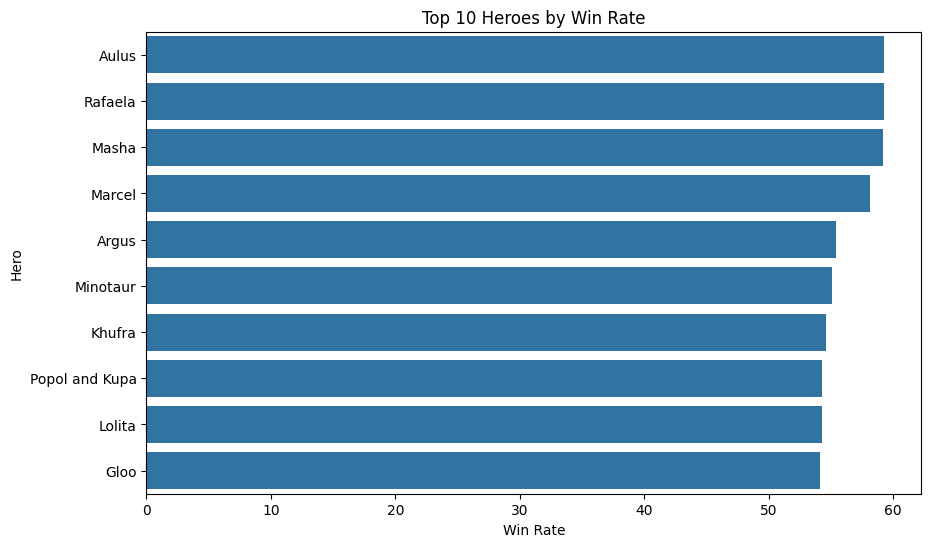

In [80]:
# Create a horizontal bar chart for the top 10 heroes by Win Rate.
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_winrate,
    x="win_rate_(%)",
    y="hero"
)

# Add descriptive labels so the chart is easy to understand.
plt.title("Top 10 Heroes by Win Rate")
plt.xlabel("Win Rate (%)")
plt.ylabel("Hero")

plt.show()

In [82]:
# Sort heroes by Win Rate from lowest to highest.
# Select the bottom 10 heroes to identify the lowest-performing heroes.
bottom_winrate = df.sort_values(
    "win_rate_(%)"
).head(10)

# Display the hero name and Win Rate for these heroes.
bottom_winrate[["hero", "win_rate_(%)"]]

,hero,win_rate_(%)
132,Franco,41.43
131,Fanny,42.76
130,Lancelot,43.36
129,Granger,43.37
128,Tigreal,44.21
127,Kalea,44.61
126,Gatotkaca,44.74
125,Zilong,45.23
124,Chou,45.30
123,Mathilda,45.46


## 5. Popularity vs Performance
Compare Pick Rate with Win Rate. Bubble size represents Ban Rate, helping us see popularity, performance, and draft pressure together.

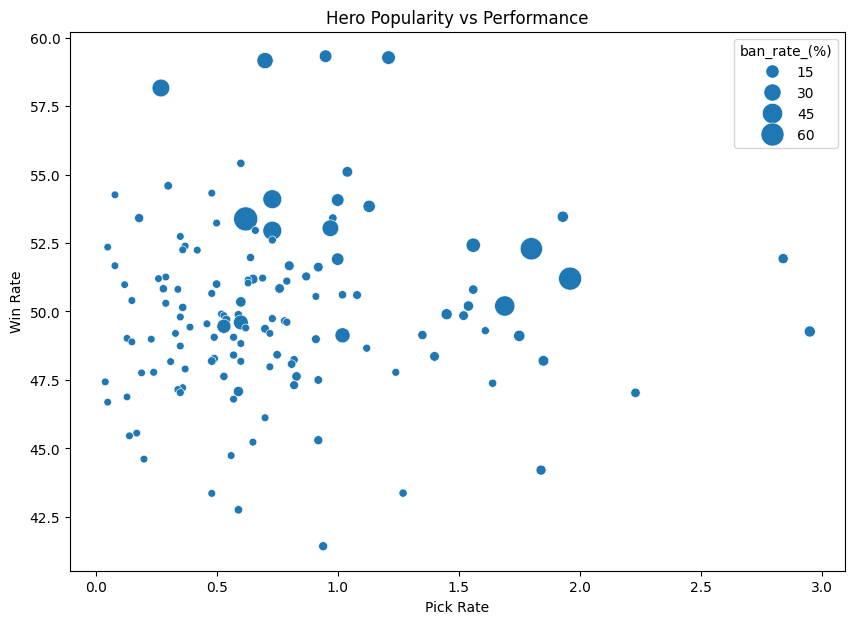

In [85]:
# Create a scatter plot to investigate whether hero popularity is related to performance.
# X-axis  = Pick Rate
# Y-axis  = Win Rate
# Bubble size = Ban Rate
#
# A larger bubble means a higher Ban Rate.
# We are looking for patterns rather than assuming that popular heroes are stronger.
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="pick_rate_(%)",
    y="win_rate_(%)",
    size="ban_rate_(%)",
    sizes=(30, 300)
)

plt.title("Hero Popularity vs Performance")
plt.xlabel("Pick Rate (%)")
plt.ylabel("Win Rate (%)")

plt.show()

## 6. Classify Heroes by Performance
Use the median Pick Rate and Win Rate as benchmarks to divide heroes into four groups: Popular & Strong, Popular but Weak, Hidden Gem, and Low Priority.

In [88]:
# Calculate the median Pick Rate, Win Rate, and Ban Rate.
# We use the median as a simple benchmark to divide heroes into performance groups.
median_pick = df["pick_rate_(%)"].median()
median_win = df["win_rate_(%)"].median()
median_ban = df["ban_rate_(%)"].median()

print("Median Pick Rate:", median_pick)
print("Median Win Rate:", median_win)
print("Median Ban Rate:", median_ban)

Median Pick Rate: 0.62
Median Win Rate: 49.7
Median Ban Rate: 1.18


In [90]:
# Create a function that classifies each hero using median Pick Rate and Win Rate.
#
# Popular & Strong   = above/equal to both medians
# Popular but Weak   = high Pick Rate but below-median Win Rate
# Hidden Gem         = below-median Pick Rate but above/equal to median Win Rate
# Low Priority       = below both medians
def classify_hero(row):

    if row["pick_rate_(%)"] >= median_pick and row["win_rate_(%)"] >= median_win:
        return "Popular & Strong"

    elif row["pick_rate_(%)"] >= median_pick and row["win_rate_(%)"] < median_win:
        return "Popular but Weak"

    elif row["pick_rate_(%)"] < median_pick and row["win_rate_(%)"] >= median_win:
        return "Hidden Gem"

    else:
        return "Low Priority" 

In [91]:
# Apply the classification function to every hero.
# The resulting category is stored in a new column called performance_category.
df["performance_category"] = df.apply(
    classify_hero,
    axis=1
)

In [92]:
# Count how many heroes belong to each performance category.
# This gives us an overview of how heroes are distributed across the four groups.
df["performance_category"].value_counts()

,count
performance_category,
Popular & Strong,38
Low Priority,36
Popular but Weak,30
Hidden Gem,29


In [98]:
# Select only the heroes classified as Hidden Gems.
# Hidden Gems have below-median Pick Rate but above/equal-to-median Win Rate.
# We sort them by Win Rate so the strongest hidden gems appear first.
hidden_gems = df[
    df["performance_category"] == "Hidden Gem"
].sort_values(
    "win_rate_(%)",
    ascending=False
)

# Display the key performance metrics for the Hidden Gems.
hidden_gems[
    ["hero", "win_rate_(%)", "pick_rate_(%)", "ban_rate_(%)"]
]

,hero,win_rate_(%),pick_rate_(%),ban_rate_(%)
3,Marcel,58.16,0.27,32.65
4,Argus,55.41,0.60,1.43
6,Khufra,54.59,0.30,1.93
7,Popol and Kupa,54.32,0.48,0.27
8,Lolita,54.26,0.08,0.17
14,Diggie,53.41,0.18,3.35
16,Bruno,53.23,0.50,0.34
20,Edith,52.74,0.35,0.22
23,Benedetta,52.39,0.37,0.29
24,Yve,52.35,0.05,0.04


In [99]:
# Check how many heroes were classified as Hidden Gems.
hidden_gems.shape

(29, 8)

## 7. Correlation Analysis
Measure relationships between the numerical variables and examine which metrics are most closely associated with Win Rate.

In [102]:
# Select only numerical columns because correlation requires numerical values.
numeric_df = df.select_dtypes(include=np.number)

In [103]:
# Calculate the correlation matrix for all numerical variables.
# Correlation values range from -1 to +1:
# +1 = strong positive relationship
#  0 = little/no linear relationship
# -1 = strong negative relationship
correlation = numeric_df.corr()

In [105]:
# Look specifically at how each numerical variable is correlated with Win Rate.
# Sorting the result helps us quickly identify the strongest relationships.
correlation["win_rate_(%)"].sort_values(
    ascending=False
)

,win_rate_(%)
win_rate_(%),1.000000
meta_score,0.540635
ban_rate_(%),0.357328
pick_rate_(%),0.036233
rank,-0.941909


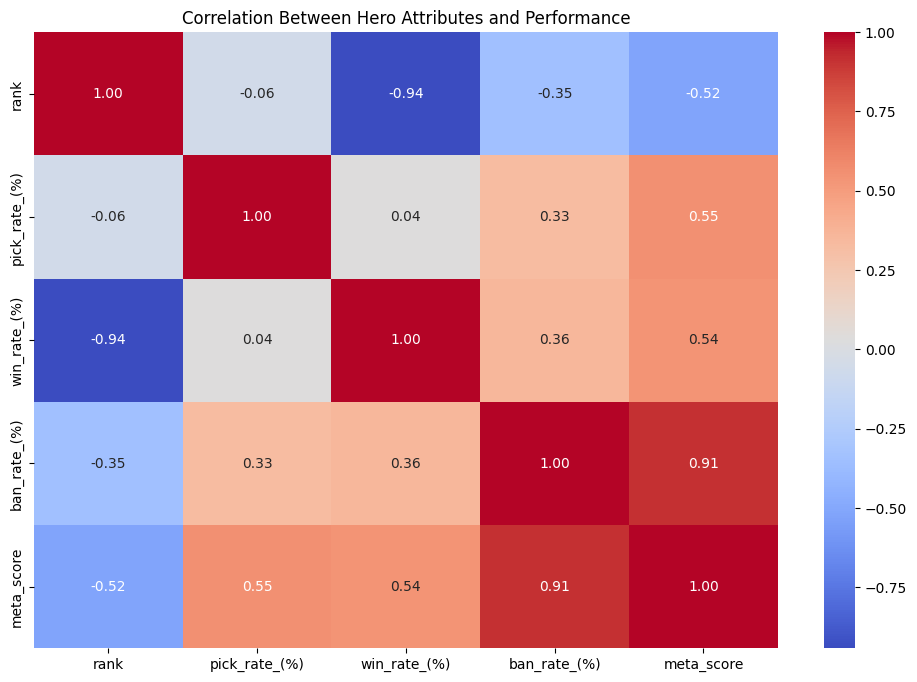

In [106]:
# Visualize the complete correlation matrix as a heatmap.
# The annotations show the correlation coefficient for each pair of variables.
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Hero Metrics and Performance")

plt.show()

## 8. Create a Meta Score
Normalize Win Rate, Pick Rate, and Ban Rate so they can be combined into one comparable score. Win Rate receives the highest weight.

In [108]:
# Min-Max Scaling converts Win Rate, Pick Rate, and Ban Rate to a common 0-to-1 scale.
# This is important because these metrics have very different numerical ranges.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[
    ["win_score", "pick_score", "ban_score"]
] = scaler.fit_transform(
    df[["win_rate_(%)", "pick_rate_(%)", "ban_rate_(%)"]]
)

In [109]:
# Create a composite Meta Score.
#
# We give the highest weight to Win Rate because it directly represents performance.
# Pick Rate represents popularity, while Ban Rate represents draft pressure.
#
# Final formula:
# Meta Score = 50% Win Score + 30% Pick Score + 20% Ban Score
df["meta_score"] = (
    0.5 * df["win_score"] +
    0.3 * df["pick_score"] +
    0.2 * df["ban_score"]
)

In [110]:
# Rank all heroes by the newly calculated Meta Score.
# The top 10 heroes are treated as the leading meta performers according to this metric.
meta_leaders = df.sort_values(
    "meta_score",
    ascending=False
).head(10)

In [114]:
# Display the top Meta Leaders along with the metrics used to evaluate them.
meta_leaders[
    ["hero", "win_rate_(%)",
     "pick_rate_(%)", "ban_rate_(%)", "meta_score"]
]

,hero,win_rate_(%),pick_rate_(%),ban_rate_(%),meta_score
1,Rafaela,59.27,1.21,16.30,0.668636
25,Belerick,52.29,1.80,55.72,0.654179
38,Eudora,51.20,1.96,59.71,0.652336
2,Masha,59.16,0.70,26.08,0.642706
0,Aulus,59.32,0.95,12.95,0.633049
29,Hanabi,51.93,2.84,5.86,0.599807
15,Hirara,53.38,0.62,65.85,0.593779
3,Marcel,58.16,0.27,32.65,0.590394
12,Obsidia,53.46,1.93,8.81,0.557719
57,Paquito,50.20,1.69,44.73,0.551027


## 9. Save the Cleaned Dataset
Export the processed dataset so it can be reused later for SQL analysis or a Power BI dashboard.

In [117]:
# Save the processed dataset so it can be reused in future analysis.
# The file can later be imported into SQL, Power BI, or another analytics tool.

import os

# Define the folder where the cleaned dataset will be stored.
data_dir = "../data"

# Create the folder if it does not already exist.
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

# Export the DataFrame without the Pandas index.
df.to_csv(
    os.path.join(data_dir, "mlbb_cleaned.csv"),
    index=False
)